In [24]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv("../data/bronze/raw_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [26]:
# Step 1: Drop irrelevant columns
df = df.drop(columns=['Conversion Rate'],axis=1)

In [27]:
#total outlier in data 

num_cols = df.select_dtypes(include=['int64','float64',]).columns
outlier_index = set()

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

Page Views : 21
Session Duration : 112
Bounce Rate : 13
Time on Page : 64
Previous Visits : 13


In [28]:
#uniqe  outlier row detection 
num_cols = df.select_dtypes(include=['int64','float64',]).columns
outlier_index = set()

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_index.update(outliers.index)



In [13]:
len(outlier_index)

216

In [ ]:
# removing outliers rows

# num_cols = df.select_dtypes(include=['int64','float64',]).columns

# for col in num_cols:
    
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
    
#     IQR = Q3 - Q1
    
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
    
#     df = df[(df[col] >= lower) & (df[col] <= upper)]

In [29]:
#cap the outlier -----Outliers ko cap kiya / clipped kiya / winsorize kiya

#Instead of removing rows, I capped the outliers using IQR boundaries so that extreme values were converted to the boundary limits.
num_cols = df.select_dtypes(include=['int64','float64',]).columns
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

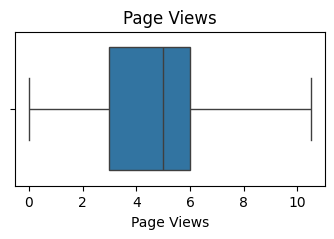

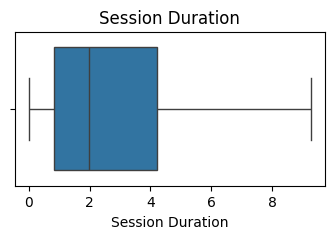

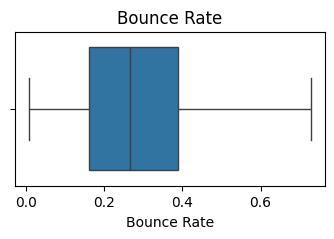

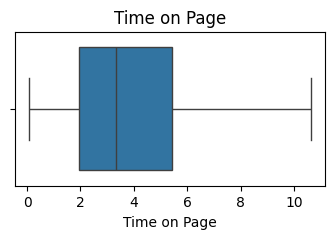

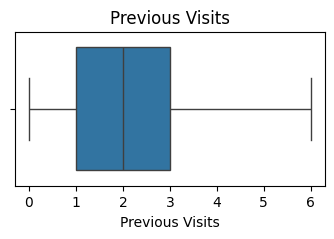

In [30]:
#after cap outlier plot -boxplot-

num_cols = df.select_dtypes(include=['int64','float64',]).columns

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

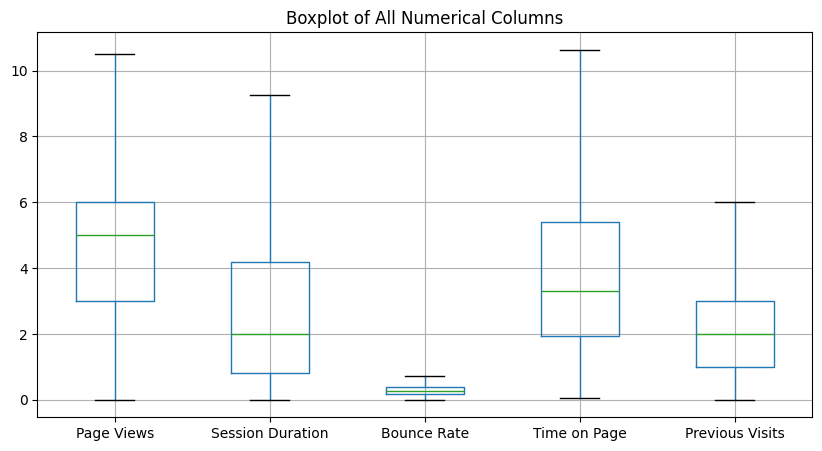

In [31]:

num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(10,5))
df[num_cols].boxplot()

plt.title("Boxplot of All Numerical Columns")
plt.show()

In [32]:
df.shape

(2000, 6)

In [33]:
df.head(5)

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits
0,5.0,9.270180,0.230652,Organic,3.890460,3
1,4.0,3.429316,0.391001,Social,8.478174,0
2,4.0,1.621052,0.397986,Organic,9.636170,2
3,5.0,3.629279,0.180458,Organic,2.071925,3
4,5.0,4.235843,0.291541,Paid,1.960654,5


In [34]:
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.940250,2.864909,0.284446,3.947783,1.970000
std,2.153572,2.609911,0.158804,2.622799,1.403954
min,0.000000,0.003613,0.007868,0.068515,0.000000
25%,3.000000,0.815828,0.161986,1.935037,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000
max,10.500000,9.270180,0.728398,10.634011,6.000000


In [35]:
df.to_csv("../data/silver/cleaned_data.csv", index=False)